# Word-Level Redundancy Experiment

This notebook tests cohesion penalization at word level. Unlike fix_red.ipynb which duplicates entire user stories,
here we inject redundancy at the word level by replacing unique words with common words from the same epic.

This simulates real-world redundancy where user stories share vocabulary even when not exact duplicates:
- "As a user, I want to set up multi-factor authentication..."
- "As a user, I want to log in using two-factor authentication..."
- "As a user, I want to securely log in using multi-factor authentication..."

In [1]:
from coeur.score import Coeur
from coeur.cohesion import CohesionScore
from sentence_transformers import SentenceTransformer
from sklearn.cluster import SpectralClustering
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
coeur_scorer = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
                     remove_re_se_stopwords=True)
dataset = "trident"
R, B = coeur_scorer.load_data(ref_path=f"datasets/{dataset}/{dataset}_specs.pdf",
                cand_path=f"datasets/{dataset}/{dataset}_backlog.csv")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
EMBEDDER = SentenceTransformer("all-mpnet-base-v2")
N_EPIC = B["epic"].nunique()
PHI = SpectralClustering(n_clusters=N_EPIC, random_state=42)
LEMM = True
STEM = True
REMOVE_STOPWORDS = True
INCLUDE_AC = False
REMOVE_RE_SE_STOPWORDS = True
PENALIZE_DUPLICATES = True
METRIC = "adjusted_mutual_info"
RANDOM_STATE = 42

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
coh_scorer = CohesionScore(embedder=EMBEDDER, clusterer=PHI, lemmatization=LEMM, stemming=STEM,
                    remove_stopwords=REMOVE_STOPWORDS, include_ac=INCLUDE_AC,
                    remove_re_se_stopwords=REMOVE_RE_SE_STOPWORDS, penalize_duplicates=PENALIZE_DUPLICATES,
                    random_state=RANDOM_STATE)

## Word-Level Noise Injection Function

This function injects word-level redundancy by:
1. Identifying content words (excluding stopwords and RE/SE stopwords)
2. Finding the most common words in each epic
3. Replacing a proportion of unique words with common words from the same epic

In [5]:
# RE/SE stopwords (same as in cohesion.py)
RE_SE_STOPWORDS = ["as", "a", "i", "want", "to", "so", "that", "i", "the", "and", 
                    "in", "is", "it", "of", "for", "on", "with", 
                    "this", "by", "an", "be", "are", "at", "from"]

def inject_word_level_redundancy(backlog, redundancy_factor, random_state=42):
    """
    Inject word-level redundancy by replacing unique words with common words from the same epic.
    
    Args:
        backlog: DataFrame with 'user_story' and 'epic' columns
        redundancy_factor: Proportion of content words to replace (0.0 to 1.0)
        random_state: Random seed for reproducibility
    
    Returns:
        DataFrame with noised user stories
    """
    np.random.seed(random_state)
    
    en_stop_words = set(stopwords.words('english'))
    all_stopwords = en_stop_words.union(set(RE_SE_STOPWORDS))
    
    B_noised = backlog.copy()
    
    for epic in B_noised["epic"].unique():
        epic_mask = B_noised["epic"] == epic
        epic_stories = B_noised.loc[epic_mask, "user_story"].tolist()
        
        # Collect all content words from this epic
        all_content_words = []
        for story in epic_stories:
            tokens = word_tokenize(story.lower())
            content_tokens = [w for w in tokens if w.isalnum() and w not in all_stopwords]
            all_content_words.extend(content_tokens)
        
        if len(all_content_words) == 0:
            continue
            
        # Find most common words in this epic
        word_counts = Counter(all_content_words)
        most_common_words = [word for word, _ in word_counts.most_common(5)]
        
        if len(most_common_words) == 0:
            continue
        
        # Process each story in the epic
        noised_stories = []
        for story in epic_stories:
            tokens = word_tokenize(story)
            noised_tokens = []
            
            for token in tokens:
                token_lower = token.lower()
                # Check if this is a content word we might replace
                if token_lower.isalnum() and token_lower not in all_stopwords:
                    # With probability = redundancy_factor, replace with a common word
                    if np.random.random() < redundancy_factor:
                        replacement = np.random.choice(most_common_words)
                        # Preserve capitalization
                        if token[0].isupper():
                            replacement = replacement.capitalize()
                        noised_tokens.append(replacement)
                    else:
                        noised_tokens.append(token)
                else:
                    noised_tokens.append(token)
            
            # Reconstruct the story
            noised_story = ' '.join(noised_tokens)
            # Fix spacing around punctuation
            noised_story = noised_story.replace(' ,', ',').replace(' .', '.').replace(' !', '!')
            noised_story = noised_story.replace(' ?', '?').replace(' :', ':').replace(' ;', ';')
            noised_stories.append(noised_story)
        
        B_noised.loc[epic_mask, "user_story"] = noised_stories
    
    return B_noised

## Example: Word-Level Noise

In [6]:
# Show example of word-level noise injection
print("Original stories (first 3):")
for i, story in enumerate(B["user_story"].head(3)):
    print(f"{i+1}. {story}")
    
print("\n" + "="*80 + "\n")

B_noised_example = inject_word_level_redundancy(B, redundancy_factor=0.5, random_state=42)
print("Noised stories (redundancy_factor=0.5):")
for i, story in enumerate(B_noised_example["user_story"].head(3)):
    print(f"{i+1}. {story}")

Original stories (first 3):
1. As a collection manager or cataloger I want to be able to see who last edited a record and when.
2. As a collection manager I want to restrict who has create/update/delete access to records in my collection.
3. As a collection manager I want to restrict who has edit access to individual records in my collection.


Noised stories (redundancy_factor=0.5):
1. As a records records or cataloger I want to be restrict to records who last edited a manager and when.
2. As a collection manager I want to access who has create/update/delete access to records in my collection.
3. As a restrict access I want to restrict who has restrict access to individual restrict in my collection.


## Run Experiment: Cohesion vs Word-Level Redundancy

Redundancy Factor: 0.00, Cohesion Score: 0.3694
Redundancy Factor: 0.25, Cohesion Score: 0.3788
Redundancy Factor: 0.50, Cohesion Score: 0.3447
Redundancy Factor: 0.75, Cohesion Score: 0.2653
Redundancy Factor: 1.00, Cohesion Score: 0.1519


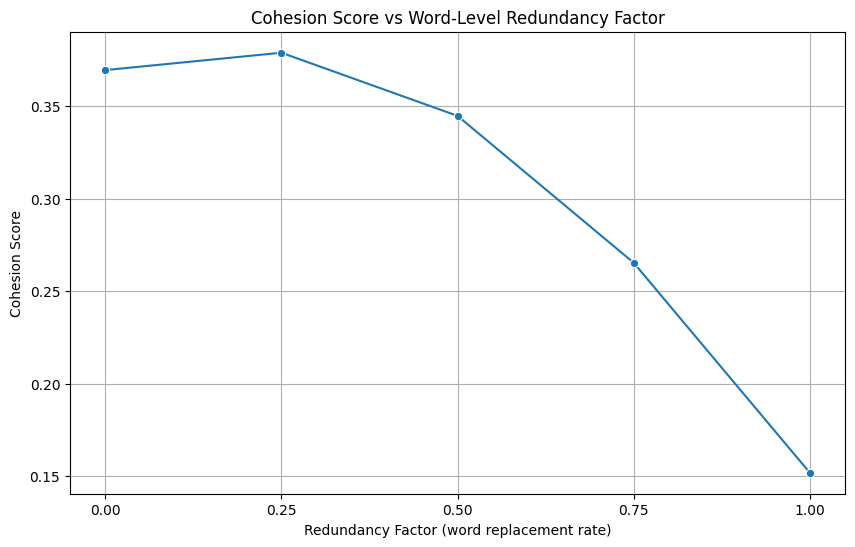

In [7]:
redundancy_factors = [0.0, 0.25, 0.5, 0.75, 1.0]
coh_results = {}

for factor in redundancy_factors:
    B_noised = inject_word_level_redundancy(B, redundancy_factor=factor, random_state=42)
    
    coh_score = coh_scorer.fit(B_noised)[METRIC]
    coh_results[factor] = coh_score
    print(f"Redundancy Factor: {factor:.2f}, Cohesion Score: {coh_score:.4f}")

# Prepare data for plotting
factors = list(coh_results.keys())
scores = list(coh_results.values())
plot_data = pd.DataFrame({"Redundancy Factor": factors, "Cohesion Score": scores})

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_data, x="Redundancy Factor", y="Cohesion Score", marker="o")
plt.title("Cohesion Score vs Word-Level Redundancy Factor")
plt.xlabel("Redundancy Factor (word replacement rate)")
plt.ylabel("Cohesion Score")
plt.xticks(factors)
plt.grid()
plt.show()

In [8]:
# Show diversity penalties
coh_scorer.penalities

[0.3488372093023256,
 0.28604651162790695,
 0.23488372093023255,
 0.16511627906976745,
 0.08372093023255814]

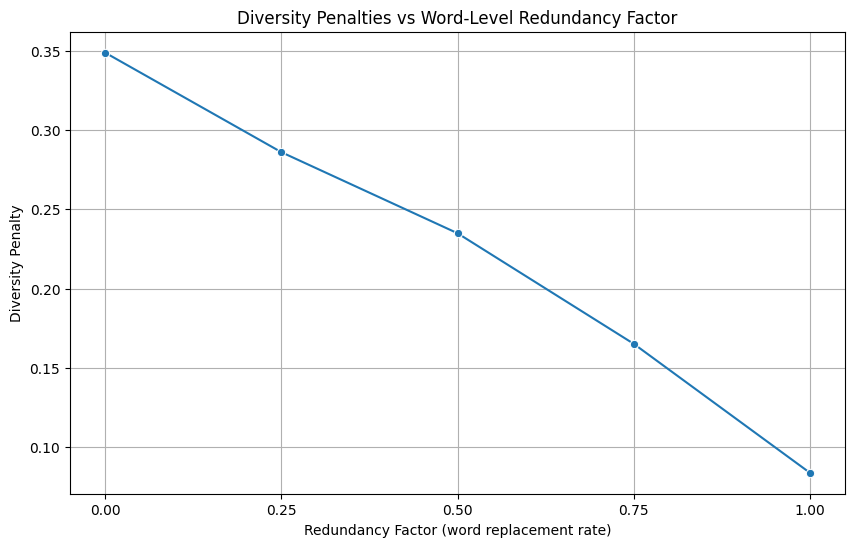

In [9]:
# Plot diversity penalties vs redundancy factor
plt.figure(figsize=(10, 6))
sns.lineplot(x=redundancy_factors, y=coh_scorer.penalities, marker="o")
plt.title("Diversity Penalties vs Word-Level Redundancy Factor")
plt.xlabel("Redundancy Factor (word replacement rate)")
plt.ylabel("Diversity Penalty")
plt.xticks(factors)
plt.grid()
plt.show()

## Comparison: With vs Without Penalty

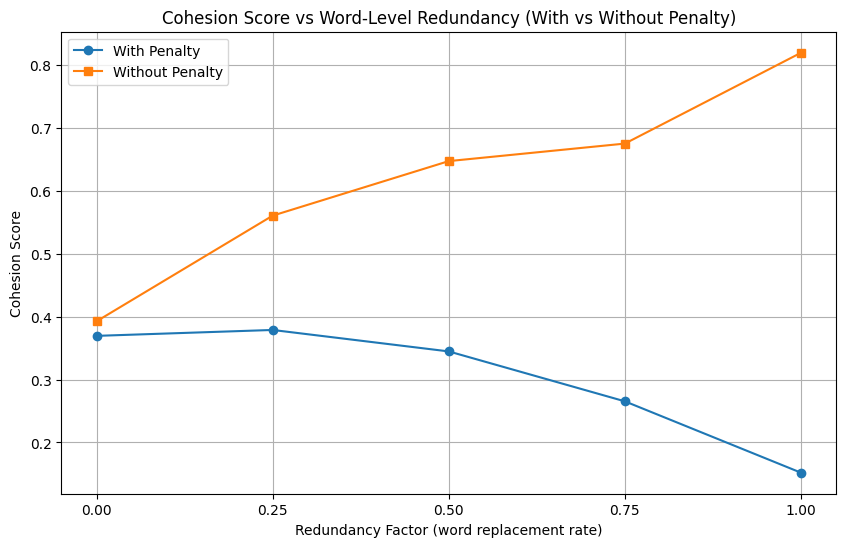

In [10]:
# Run without penalty for comparison
coh_scorer_no_penalty = CohesionScore(embedder=EMBEDDER, clusterer=PHI, lemmatization=LEMM, stemming=STEM,
                    remove_stopwords=REMOVE_STOPWORDS, include_ac=INCLUDE_AC,
                    remove_re_se_stopwords=REMOVE_RE_SE_STOPWORDS, penalize_duplicates=False,
                    random_state=RANDOM_STATE)

coh_results_no_penalty = {}
for factor in redundancy_factors:
    B_noised = inject_word_level_redundancy(B, redundancy_factor=factor, random_state=42)
    coh_score = coh_scorer_no_penalty.fit(B_noised)[METRIC]
    coh_results_no_penalty[factor] = coh_score

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(factors, list(coh_results.values()), marker='o', label='With Penalty')
plt.plot(factors, list(coh_results_no_penalty.values()), marker='s', label='Without Penalty')
plt.title("Cohesion Score vs Word-Level Redundancy (With vs Without Penalty)")
plt.xlabel("Redundancy Factor (word replacement rate)")
plt.ylabel("Cohesion Score")
plt.legend()
plt.xticks(factors)
plt.grid()
plt.show()

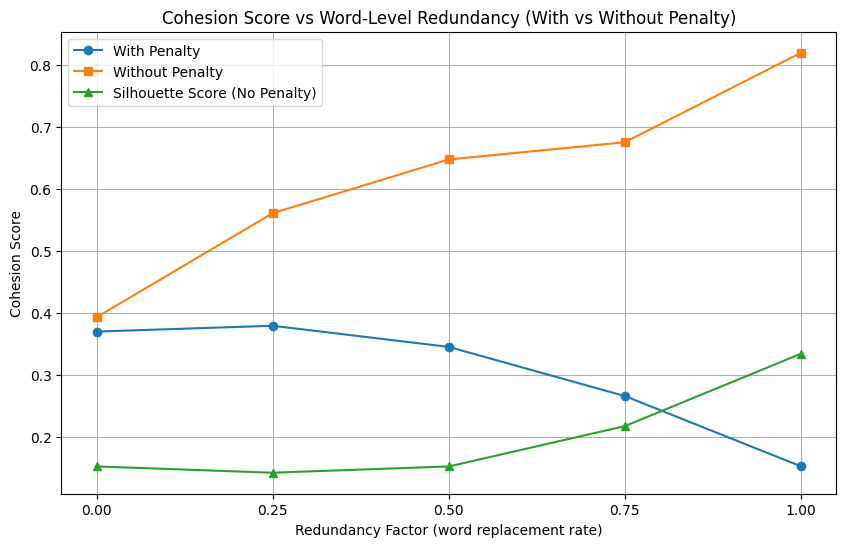

In [12]:
# Run without penalty for comparison
coh_scorer_no_penalty = CohesionScore(embedder=EMBEDDER, clusterer=PHI, lemmatization=LEMM, stemming=STEM,
                    remove_stopwords=REMOVE_STOPWORDS, include_ac=INCLUDE_AC,
                    remove_re_se_stopwords=REMOVE_RE_SE_STOPWORDS, penalize_duplicates=False,
                    random_state=RANDOM_STATE)

coh_results_no_penalty = {}
silhouette_scores_no_penalty = {}
for factor in redundancy_factors:
    B_noised = inject_word_level_redundancy(B, redundancy_factor=factor, random_state=42)
    coh_score = coh_scorer_no_penalty.fit(B_noised)

    coh_results_no_penalty[factor] = coh_score["adjusted_mutual_info"]
    silhouette_scores_no_penalty[factor] = coh_score["silhouette"]

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(factors, list(coh_results.values()), marker='o', label='With Penalty')
plt.plot(factors, list(coh_results_no_penalty.values()), marker='s', label='Without Penalty')
plt.plot(factors, list(silhouette_scores_no_penalty.values()), marker='^', label='Silhouette Score (No Penalty)')
plt.title("Cohesion Score vs Word-Level Redundancy (With vs Without Penalty)")
plt.xlabel("Redundancy Factor (word replacement rate)")
plt.ylabel("Cohesion Score")
plt.legend()
plt.xticks(factors)
plt.grid()
plt.show()

## Detailed Analysis: Word Diversity per Epic

In [11]:
# Show diversity factors per epic for each redundancy level
print("Diversity factors per epic for each redundancy level:")
print("="*60)
for i, factor in enumerate(redundancy_factors):
    print(f"\nRedundancy Factor {factor}:")
    if i < len(coh_scorer.diversity_factors):
        factors_per_epic = coh_scorer.diversity_factors[i]
        print(f"  Mean: {np.mean(factors_per_epic):.4f}, Min: {np.min(factors_per_epic):.4f}, Max: {np.max(factors_per_epic):.4f}")

Diversity factors per epic for each redundancy level:

Redundancy Factor 0.0:
  Mean: 0.3488, Min: 0.3488, Max: 0.3488

Redundancy Factor 0.25:
  Mean: 0.2860, Min: 0.2860, Max: 0.2860

Redundancy Factor 0.5:
  Mean: 0.2349, Min: 0.2349, Max: 0.2349

Redundancy Factor 0.75:
  Mean: 0.1651, Min: 0.1651, Max: 0.1651

Redundancy Factor 1.0:
  Mean: 0.0837, Min: 0.0837, Max: 0.0837
